# 09 — Level vs Numeric Feature Encoding Comparison

Notebook này tổng hợp kết quả từ notebook `08a` (level feature representation) và `08b` (numeric feature representation) để chọn candidate tốt nhất cho bước tuning tiếp theo.

Notebook so sánh hai hướng biểu diễn feature (`level` và `numeric`) cùng hai target strategy (`target_price` và `log_target_price`). Trọng tâm của notebook là chọn candidate tốt nhất để đưa sang bước tuning tiếp theo.

Dựa trên kết quả từ notebook 08a và 08b, `target_price` được chọn làm target chính vì cho hiệu năng cân bằng hơn trên thang giá thật. Mặc dù `log_target_price` có thể cải thiện MAE/MAPE nhẹ ở một số mô hình, mức cải thiện này không đủ lớn để bù lại việc RMSE cao hơn hoặc R² thấp hơn. Vì vậy, `log_target_price` được giữ làm candidate phụ, không phải hướng chính.

Không train lại model. Tất cả metric được load từ CSV artifacts của notebook `08a` và `08b`, hoặc lấy từ fallback values nếu CSV không tồn tại.

Tất cả metric trong notebook này được diễn giải trên **thang giá gốc, đơn vị triệu VND**.


## 1. Imports and Configuration

In [23]:
from __future__ import annotations

import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

# ── Paths ─────────────────────────────────────────────────────────────────────
PROJECT_ROOT   = Path.cwd().resolve().parents[1]

ARTIFACT_LEVEL   = PROJECT_ROOT / 'artifacts' / 'modeling_level'   / 'target_comparison'
ARTIFACT_NUMERIC = PROJECT_ROOT / 'artifacts' / 'modeling_numeric'  / 'target_comparison'

OUTPUT_DIR = PROJECT_ROOT / 'artifacts' / 'level_numeric_comparison'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Constants ─────────────────────────────────────────────────────────────────
STRONG_MODELS     = ['CatBoost', 'LightGBM']
PRICE_SCALE       = 'target_price'
MAE_TOLERANCE     = 0.02   # candidates within 2% of best MAE are treated as near-best
CLOSE_THRESHOLD   = 0.03   # 3% — differences below this are treated as marginal/tie
RMSE_PENALTY_CAP  = 0.05   # used only to describe the log-target trade-off

print(f'PROJECT_ROOT    : {PROJECT_ROOT}')
print(f'ARTIFACT_LEVEL  : {ARTIFACT_LEVEL}')
print(f'ARTIFACT_NUMERIC: {ARTIFACT_NUMERIC}')
print(f'OUTPUT_DIR      : {OUTPUT_DIR}')
print(f'PRICE_SCALE     : {PRICE_SCALE}')
print(f'MAE_TOLERANCE   : {MAE_TOLERANCE*100:.0f}%  — near-best MAE band for balanced selection')
print(f'CLOSE_THRESHOLD : {CLOSE_THRESHOLD*100:.0f}%  — dưới ngưỡng này coi là tie')
print(f'RMSE_PENALTY_CAP: {RMSE_PENALTY_CAP*100:.0f}%  — ngưỡng tham khảo khi đánh giá log target')

# ── Report artifact mirroring ─────────────────────────────────────────────────
# Keep the original artifact paths for downstream notebooks, and mirror every
# generated table/figure into reports/tables and reports/figures for the report.
NOTEBOOK_SLUG = "09_level_numeric_comparison"
REPORT_DIR = PROJECT_ROOT / "reports"
REPORT_FIGURES_DIR = REPORT_DIR / "figures" / NOTEBOOK_SLUG
REPORT_TABLES_DIR = REPORT_DIR / "tables" / NOTEBOOK_SLUG
for directory in [REPORT_FIGURES_DIR, REPORT_TABLES_DIR]:
    directory.mkdir(parents=True, exist_ok=True)


def _report_relative_path(path):
    path = Path(path)
    try:
        path = path.resolve()
    except OSError:
        path = path.absolute()
    for base in [PROJECT_ROOT / "artifacts", PROJECT_ROOT / "reports", PROJECT_ROOT]:
        try:
            return path.relative_to(base.resolve())
        except ValueError:
            continue
    return Path(path.name)


def _mirror_report_artifact(path, destination_root):
    if path is None or destination_root is None or not isinstance(path, (str, Path)):
        return
    src = Path(path)
    if not src.exists() or not src.is_file():
        return
    rel = _report_relative_path(src)
    dst = destination_root / rel
    try:
        if src.resolve() == dst.resolve():
            return
    except OSError:
        pass
    dst.parent.mkdir(parents=True, exist_ok=True)
    shutil.copy2(src, dst)


import shutil
from matplotlib.figure import Figure

if not hasattr(pd.DataFrame, "_reports_original_to_csv"):
    pd.DataFrame._reports_original_to_csv = pd.DataFrame.to_csv
if not hasattr(pd.Series, "_reports_original_to_csv"):
    pd.Series._reports_original_to_csv = pd.Series.to_csv
if not hasattr(pd.DataFrame, "_reports_original_to_excel"):
    pd.DataFrame._reports_original_to_excel = pd.DataFrame.to_excel
if not hasattr(Figure, "_reports_original_savefig"):
    Figure._reports_original_savefig = Figure.savefig


def _to_csv_with_report_mirror(self, path_or_buf=None, *args, **kwargs):
    result = pd.DataFrame._reports_original_to_csv(self, path_or_buf, *args, **kwargs)
    _mirror_report_artifact(path_or_buf, globals().get("REPORT_TABLES_DIR"))
    return result


def _series_to_csv_with_report_mirror(self, path_or_buf=None, *args, **kwargs):
    result = pd.Series._reports_original_to_csv(self, path_or_buf, *args, **kwargs)
    _mirror_report_artifact(path_or_buf, globals().get("REPORT_TABLES_DIR"))
    return result


def _to_excel_with_report_mirror(self, excel_writer, *args, **kwargs):
    result = pd.DataFrame._reports_original_to_excel(self, excel_writer, *args, **kwargs)
    _mirror_report_artifact(excel_writer, globals().get("REPORT_TABLES_DIR"))
    return result


def _savefig_with_report_mirror(self, fname, *args, **kwargs):
    result = Figure._reports_original_savefig(self, fname, *args, **kwargs)
    _mirror_report_artifact(fname, globals().get("REPORT_FIGURES_DIR"))
    return result


_to_csv_with_report_mirror._reports_mirror_patch = True
_series_to_csv_with_report_mirror._reports_mirror_patch = True
_to_excel_with_report_mirror._reports_mirror_patch = True
_savefig_with_report_mirror._reports_mirror_patch = True
pd.DataFrame.to_csv = _to_csv_with_report_mirror
pd.Series.to_csv = _series_to_csv_with_report_mirror
pd.DataFrame.to_excel = _to_excel_with_report_mirror
Figure.savefig = _savefig_with_report_mirror

print(f"Report figures mirrored to: {REPORT_FIGURES_DIR}")
print(f"Report tables mirrored to : {REPORT_TABLES_DIR}")


PROJECT_ROOT    : Y:\Python\Laptop-Price-Prediction
ARTIFACT_LEVEL  : Y:\Python\Laptop-Price-Prediction\artifacts\modeling_level\target_comparison
ARTIFACT_NUMERIC: Y:\Python\Laptop-Price-Prediction\artifacts\modeling_numeric\target_comparison
OUTPUT_DIR      : Y:\Python\Laptop-Price-Prediction\artifacts\level_numeric_comparison
PRICE_SCALE     : target_price
MAE_TOLERANCE   : 2%  — near-best MAE band for balanced selection
CLOSE_THRESHOLD : 3%  — dưới ngưỡng này coi là tie
RMSE_PENALTY_CAP: 5%  — ngưỡng tham khảo khi đánh giá log target
Report figures mirrored to: Y:\Python\Laptop-Price-Prediction\reports\figures\09_level_numeric_comparison
Report tables mirrored to : Y:\Python\Laptop-Price-Prediction\reports\tables\09_level_numeric_comparison


## 2. Load Previous Results

Load `target_comparison_overall_ranking.csv` từ notebook 08a/08b.
Nếu CSV không tồn tại, dùng fallback DataFrame từ kết luận đã công bố của notebook 08.

> **Fallback values** lấy trực tiếp từ kết luận của notebook 08a và 08b.


In [24]:
# ── Helper: load metrics CSV ──────────────────────────────────────────────────
def load_metrics_csv(artifact_dir: Path, encoding_type: str) -> pd.DataFrame | None:
    """Try to load target_comparison_overall_ranking.csv; fall back to model_metrics.csv."""
    candidates = [
        artifact_dir / 'target_comparison_overall_ranking.csv',
        artifact_dir.parent / 'metrics' / 'model_metrics.csv',
        artifact_dir.parent / 'metrics' / 'metrics_df.csv',
        artifact_dir.parent / 'metrics' / 'all_metrics.csv',
    ]
    for path in candidates:
        if path.exists():
            df = pd.read_csv(path)
            df.columns = [c.strip().lower().replace(' ', '_').replace('-', '_')
                          for c in df.columns]
            df['encoding_type'] = encoding_type
            print(f'  Loaded: {path.name}  shape={df.shape}')
            return df
    return None


print('=== Loading level encoding results (08a) ===')
df_level = load_metrics_csv(ARTIFACT_LEVEL, 'level')

print()
print('=== Loading numeric encoding results (08b) ===')
df_numeric = load_metrics_csv(ARTIFACT_NUMERIC, 'numeric')


=== Loading level encoding results (08a) ===
  Loaded: target_comparison_overall_ranking.csv  shape=(16, 11)

=== Loading numeric encoding results (08b) ===
  Loaded: target_comparison_overall_ranking.csv  shape=(16, 11)


In [25]:
# ── Fallback: hardcoded values from the current notebook 08 conclusions ───────
FALLBACK_ROWS = [
    # Level representation (08a)
    dict(model_name='CatBoost',  model_type='gradient_boosting', encoding_type='level',
         target_used='target_price', evaluation_scale='target_price',
         rmse=5.4826687960, mae=3.3708874266, mape=0.3001381413, r2=0.8870056032),
    dict(model_name='LightGBM',  model_type='gradient_boosting', encoding_type='level',
         target_used='target_price', evaluation_scale='target_price',
         rmse=5.4980802849, mae=3.2903954453, mape=0.2816584850, r2=0.8863694679),
    dict(model_name='LightGBM',  model_type='gradient_boosting', encoding_type='level',
         target_used='log_target_price', evaluation_scale='target_price',
         rmse=5.5299727295, mae=3.2534667368, mape=0.2704267475, r2=0.8850473820),
    dict(model_name='CatBoost',  model_type='gradient_boosting', encoding_type='level',
         target_used='log_target_price', evaluation_scale='target_price',
         rmse=5.7407188259, mae=3.3369722071, mape=0.2856438843, r2=0.8761187900),
    # Numeric representation (08b)
    dict(model_name='LightGBM',  model_type='gradient_boosting', encoding_type='numeric',
         target_used='target_price', evaluation_scale='target_price',
         rmse=5.3364657964, mae=3.2245794645, mape=0.2733688742, r2=0.8929515592),
    dict(model_name='CatBoost',  model_type='gradient_boosting', encoding_type='numeric',
         target_used='target_price', evaluation_scale='target_price',
         rmse=5.4136348122, mae=3.3103716013, mape=0.2911762554, r2=0.8898331839),
    dict(model_name='LightGBM',  model_type='gradient_boosting', encoding_type='numeric',
         target_used='log_target_price', evaluation_scale='target_price',
         rmse=5.5068574062, mae=3.2177689985, mape=0.2683209189, r2=0.8860063790),
    dict(model_name='CatBoost',  model_type='gradient_boosting', encoding_type='numeric',
         target_used='log_target_price', evaluation_scale='target_price',
         rmse=5.7275312688, mae=3.3061872265, mape=0.2780735575, r2=0.8766872950),
]
FALLBACK_DF = pd.DataFrame(FALLBACK_ROWS)


In [26]:
# ── Merge or fall back ────────────────────────────────────────────────────────
def infer_model_type(model_name: str) -> str:
    name = str(model_name).strip().lower()
    if name in {'linear regression', 'ridge', 'lasso', 'elasticnet', 'elastic net'}:
        return 'linear'
    if name in {'catboost', 'lightgbm', 'xgboost'}:
        return 'gradient_boosting'
    if name in {'random forest', 'extra trees'}:
        return 'tree_ensemble'
    return 'other'


def extract_results(df: pd.DataFrame, encoding: str) -> pd.DataFrame:
    """Standardise result columns from notebook 08 artifacts."""
    col_map = {
        'model_name': 'model_name',
        'model_type': 'model_type',
        'target_used': 'target_used',
        'evaluation_scale': 'evaluation_scale',
        'rmse': 'rmse',
        'mae': 'mae',
        'mape': 'mape',
        'r2': 'r2',
        'max_error': 'max_error',
    }
    available = [c for c in col_map if c in df.columns]
    out = df[available].rename(columns={c: col_map[c] for c in available}).copy()
    out['encoding_type'] = encoding

    def normalise(name):
        n = str(name).strip().lower()
        if 'catboost' in n:
            return 'CatBoost'
        if 'lightgbm' in n or 'light gbm' in n:
            return 'LightGBM'
        if 'random forest' in n:
            return 'Random Forest'
        if 'extra trees' in n:
            return 'Extra Trees'
        if 'linear' in n:
            return 'Linear Regression'
        if 'ridge' in n:
            return 'Ridge'
        if 'lasso' in n:
            return 'Lasso'
        if 'elastic' in n:
            return 'ElasticNet'
        return str(name).strip()

    out['model_name'] = out['model_name'].apply(normalise)
    if 'model_type' not in out.columns:
        out['model_type'] = out['model_name'].apply(infer_model_type)
    if 'evaluation_scale' not in out.columns:
        out['evaluation_scale'] = PRICE_SCALE
    if 'mape' in out.columns and out['mape'].max(skipna=True) > 5:
        out['mape'] = out['mape'] / 100.0
    return out.reset_index(drop=True)


parts = []
if df_level is not None:
    parts.append(extract_results(df_level, 'level'))
if df_numeric is not None:
    parts.append(extract_results(df_numeric, 'numeric'))

if parts:
    combined_df = pd.concat(parts, ignore_index=True)
    data_source = 'CSV artifacts từ notebook 08a / 08b'
else:
    combined_df = FALLBACK_DF.copy()
    data_source = 'Fallback: giá trị hardcoded từ kết luận notebook 08 hiện tại'

all_results = combined_df.copy()

print(f'Data source : {data_source}')
print(f'Shape       : {all_results.shape}')
print()
display(all_results)


Data source : CSV artifacts từ notebook 08a / 08b
Shape       : (32, 9)



,model_name,target_used,rmse,mae,mape,r2,encoding_type,model_type,evaluation_scale
0,CatBoost,target_price,5.4827,3.3709,0.3001,0.8870,level,gradient_boosting,target_price
1,LightGBM,target_price,5.4981,3.2904,0.2817,0.8864,level,gradient_boosting,target_price
2,LightGBM,log_target_price,5.5300,3.2535,0.2627,0.8850,level,gradient_boosting,target_price
3,Random Forest,target_price,5.6870,3.4085,0.3021,0.8784,level,tree_ensemble,target_price
4,CatBoost,log_target_price,5.7407,3.3370,0.2621,0.8761,level,gradient_boosting,target_price
5,Random Forest,log_target_price,5.8456,3.4134,0.2830,0.8715,level,tree_ensemble,target_price
6,Extra Trees,target_price,5.9386,3.5442,0.3095,0.8674,level,tree_ensemble,target_price
7,Extra Trees,log_target_price,6.0317,3.5166,0.2936,0.8632,level,tree_ensemble,target_price
8,Linear Regression,log_target_price,6.9260,4.0736,0.3191,0.8197,level,linear,target_price
9,Lasso,log_target_price,6.9425,4.0807,0.3196,0.8188,level,linear,target_price


## 3. Filter Strong Models

In [27]:
# Main comparison focuses on the strongest boosting models from notebook 08.
main_df = all_results[all_results['model_name'].isin(STRONG_MODELS)].copy()

for col in ['rmse', 'mae', 'mape', 'r2']:
    if col not in main_df.columns:
        main_df[col] = np.nan

main_df = main_df.reset_index(drop=True)

print(f'Strong-model rows : {len(main_df)}')
print(f'Models            : {main_df["model_name"].unique().tolist()}')
print(f'Encodings         : {main_df["encoding_type"].unique().tolist()}')
print(f'Targets           : {main_df["target_used"].unique().tolist()}')
print(f'Evaluation scales : {main_df["evaluation_scale"].unique().tolist()}')


Strong-model rows : 8
Models            : ['CatBoost', 'LightGBM']
Encodings         : ['level', 'numeric']
Targets           : ['target_price', 'log_target_price']
Evaluation scales : ['target_price']


> **Nhận xét:** Tổng cộng 8 cấu hình được phân tích: 2 model × 2 encoding × 2 target.
> Đây là không gian đủ lớn để so sánh có ý nghĩa mà không bị nhiễu bởi các model yếu hơn.


## 4. Main Comparison Table

Toàn bộ 8 cấu hình, sắp xếp theo MAE tăng dần (metric chính).
Ô xanh đánh dấu giá trị tốt nhất mỗi cột.


In [28]:
# ── Highlight helper ────────────────────────────────────────────────────────
def highlight_best(s):
    """Highlight minimum error / maximum R²."""
    if s.name in ('rmse', 'mae', 'mape'):
        best = s.min()
        return ['background-color: #c6efce; font-weight: bold' if v == best else '' for v in s]
    if s.name == 'r2':
        best = s.max()
        return ['background-color: #c6efce; font-weight: bold' if v == best else '' for v in s]
    return ['' for _ in s]


table_df = (
    main_df[['model_name', 'encoding_type', 'target_used', 'rmse', 'mae', 'mape', 'r2']]
    .sort_values(['mae', 'mape', 'rmse'])
    .reset_index(drop=True)
)
table_df.index += 1

print('=== Main Comparison Table (sorted by MAE ascending) ===')
display(
    table_df.style
    .apply(highlight_best, subset=['rmse', 'mae', 'mape', 'r2'])
    .format({'rmse': '{:,.4f}', 'mae': '{:,.4f}', 'mape': '{:.4f}', 'r2': '{:.4f}'})
)

table_df.to_csv(OUTPUT_DIR / 'main_comparison_table.csv')
print('Saved: main_comparison_table.csv')


=== Main Comparison Table (sorted by MAE ascending) ===


,model_name,encoding_type,target_used,rmse,mae,mape,r2
1,LightGBM,numeric,log_target_price,5.5069,3.2178,0.2517,0.8860
2,LightGBM,numeric,target_price,5.3365,3.2246,0.2734,0.8930
3,LightGBM,level,log_target_price,5.5300,3.2535,0.2627,0.8850
4,LightGBM,level,target_price,5.4981,3.2904,0.2817,0.8864
5,CatBoost,numeric,log_target_price,5.7275,3.3062,0.2544,0.8767
6,CatBoost,numeric,target_price,5.4136,3.3104,0.2912,0.8898
7,CatBoost,level,log_target_price,5.7407,3.3370,0.2621,0.8761
8,CatBoost,level,target_price,5.4827,3.3709,0.3001,0.8870


Saved: main_comparison_table.csv


> **Nhận xét bảng chính:**
> - Nhóm gradient boosting tiếp tục là nhóm mô hình mạnh nhất, với `LightGBM` và `CatBoost` là hai mô hình cần giữ để so sánh.
> - `LightGBM + target_price` trên numeric features là cấu hình cân bằng nhất trên thang giá thật: MAE gần best, đồng thời RMSE thấp và R² cao.
> - `LightGBM + log_target_price` có thể cải thiện MAE/MAPE nhẹ, nhưng mức cải thiện nhỏ so với phần mất mát ở RMSE/R² sau inverse-transform.
> - Vì mục tiêu cuối cùng là dự đoán giá laptop theo đơn vị triệu VND, `target_price` được xem là target chính; `log_target_price` là candidate phụ để kiểm tra lợi ích MAE/MAPE.


## 5. Target Comparison: target_price vs log_target_price

Với mỗi cặp (encoding, model), tính delta `log_target_price − target_price`.

- **delta < 0** → log-target tốt hơn (lỗi thấp hơn)
- **delta > 0** → direct-target tốt hơn

Sử dụng `CLOSE_THRESHOLD = 3%` để phân loại tie/winner theo tỉ lệ phần trăm.


In [29]:
target_delta_rows = []

for (enc, model), grp in main_df.groupby(['encoding_type', 'model_name']):
    pivot = grp.set_index('target_used')
    if not {'target_price', 'log_target_price'}.issubset(pivot.index):
        continue

    p = pivot.loc['target_price']
    l = pivot.loc['log_target_price']

    delta_rmse = l['rmse'] - p['rmse']
    delta_mae  = l['mae']  - p['mae']
    delta_mape = l['mape'] - p['mape']
    delta_r2   = l['r2']   - p['r2']

    mae_pct  = delta_mae  / p['mae']
    rmse_pct = delta_rmse / p['rmse']
    mape_pct = delta_mape / p['mape']

    def pct_winner(pct, label_better='log', label_worse='direct'):
        if abs(pct) <= CLOSE_THRESHOLD:
            return 'tie'
        return label_better if pct < -CLOSE_THRESHOLD else label_worse

    mae_winner  = pct_winner(mae_pct)
    rmse_winner = pct_winner(rmse_pct)
    mape_winner = pct_winner(mape_pct)

    # Balanced interpretation: small MAE/MAPE gains do not override worse RMSE/R2.
    mae_near_equal = abs(mae_pct) <= MAE_TOLERANCE
    target_controls_large_error = (p['rmse'] <= l['rmse']) and (p['r2'] >= l['r2'])
    if target_controls_large_error and (mae_near_equal or delta_mae < 0):
        rec = 'target_price primary; log_target_price alternative'
    elif delta_mae < 0 and delta_mape < 0:
        rec = 'log_target_price alternative'
    else:
        rec = 'target_price primary'

    target_delta_rows.append({
        'encoding_type'        : enc,
        'model_name'           : model,
        'delta_rmse (log−dir)' : delta_rmse,
        'delta_mae  (log−dir)' : delta_mae,
        'delta_mape (log−dir)' : delta_mape,
        'delta_r2   (log−dir)' : delta_r2,
        'mae_pct_diff'         : mae_pct,
        'rmse_pct_diff'        : rmse_pct,
        'mape_pct_diff'        : mape_pct,
        'mae_winner'           : mae_winner,
        'rmse_winner'          : rmse_winner,
        'mape_winner'          : mape_winner,
        'recommendation'       : rec,
    })

target_delta_df = pd.DataFrame(target_delta_rows).sort_values(['encoding_type', 'model_name'])

def colour_delta(val):
    try:
        return 'color: green; font-weight: bold' if val < 0 else ('color: red' if val > 0 else '')
    except TypeError:
        return ''

delta_cols = [c for c in target_delta_df.columns if c.startswith('delta')]
pct_cols   = [c for c in target_delta_df.columns if 'pct_diff' in c]

print('=== Target Comparison: log vs direct (âm = log tốt hơn cho error metrics; dương = log cao hơn) ===')
display(
    target_delta_df[['encoding_type','model_name'] + delta_cols + ['mae_winner','rmse_winner','mape_winner','recommendation']]
    .style
    .applymap(colour_delta, subset=delta_cols)
    .format({c: '{:+.4f}' for c in delta_cols})
)

target_delta_df.to_csv(OUTPUT_DIR / 'target_comparison_delta.csv', index=False)
print('Saved: target_comparison_delta.csv')


=== Target Comparison: log vs direct (âm = log tốt hơn cho error metrics; dương = log cao hơn) ===


,encoding_type,model_name,delta_rmse (log−dir),delta_mae (log−dir),delta_mape (log−dir),delta_r2 (log−dir),mae_winner,rmse_winner,mape_winner,recommendation
0,level,CatBoost,+0.2581,-0.0339,-0.0381,-0.0109,tie,direct,log,target_price primary; log_target_price alternative
1,level,LightGBM,+0.0319,-0.0369,-0.0190,-0.0013,tie,tie,log,target_price primary; log_target_price alternative
2,numeric,CatBoost,+0.3139,-0.0042,-0.0368,-0.0131,tie,direct,log,target_price primary; log_target_price alternative
3,numeric,LightGBM,+0.1704,-0.0068,-0.0217,-0.0069,tie,direct,log,target_price primary; log_target_price alternative


Saved: target_comparison_delta.csv


In [30]:
print('=== Target Recommendation per (Encoding, Model) ===')
for _, row in target_delta_df.iterrows():
    print(f"  [{row['encoding_type']:7s}] {row['model_name']:<10s}  "
          f"MAE winner: {row['mae_winner']:<6s}  "
          f"RMSE winner: {row['rmse_winner']:<6s}  "
          f"mae_pct={row['mae_pct_diff']:+.2%}  "
          f"→ {row['recommendation']}")


=== Target Recommendation per (Encoding, Model) ===
  [level  ] CatBoost    MAE winner: tie     RMSE winner: direct  mae_pct=-1.01%  → target_price primary; log_target_price alternative
  [level  ] LightGBM    MAE winner: tie     RMSE winner: tie     mae_pct=-1.12%  → target_price primary; log_target_price alternative
  [numeric] CatBoost    MAE winner: tie     RMSE winner: direct  mae_pct=-0.13%  → target_price primary; log_target_price alternative
  [numeric] LightGBM    MAE winner: tie     RMSE winner: direct  mae_pct=-0.21%  → target_price primary; log_target_price alternative


> **Nhận xét Target Comparison:**
> - `log_target_price` vẫn là một candidate phụ đáng giữ lại vì có thể cải thiện MAE/MAPE.
> - Tuy nhiên, trong kết quả hiện tại, lợi ích này khá nhỏ. Khi xét hiệu năng tổng thể trên price scale, `target_price` cho kết quả cân bằng hơn, đặc biệt về RMSE và R².
> - Vì bài toán là dự đoán giá laptop trên thang triệu VND, notebook chọn `target_price` làm target chính và giữ `log_target_price` làm alternative để so sánh trong bước tuning.


## 6. RMSE Penalty Analysis for log_target_price

Bảng này định lượng rõ trade-off khi chọn `log_target_price` thay vì `target_price`:
- RMSE tăng bao nhiêu phần trăm (`rmse_penalty_pct`)?
- MAE và MAPE cải thiện bao nhiêu (`mae_improvement_pct`, `mape_improvement_pct`)?
- Có chấp nhận log không (`accept_log`)?

**Logic accept_log:** `True` nếu MAE hoặc MAPE cải thiện VÀ RMSE penalty ≤ 5%.


In [31]:
rmse_penalty_rows = []

for (model, enc), grp in main_df.groupby(['model_name', 'encoding_type']):
    pivot = grp.set_index('target_used')
    if not {'target_price', 'log_target_price'}.issubset(pivot.index):
        continue

    p = pivot.loc['target_price']
    l = pivot.loc['log_target_price']

    rmse_penalty_pct     = (l['rmse'] - p['rmse']) / p['rmse'] * 100
    mae_improvement_pct  = (p['mae']  - l['mae'])  / p['mae']  * 100   # positive = log better
    mape_improvement_pct = (p['mape'] - l['mape']) / p['mape'] * 100
    r2_delta             = l['r2'] - p['r2']

    keep_log_candidate = (mae_improvement_pct > 0) or (mape_improvement_pct > 0)
    target_more_balanced = (rmse_penalty_pct > 0) and (r2_delta < 0) and (mae_improvement_pct <= MAE_TOLERANCE * 100)

    rmse_penalty_rows.append({
        'model_name'            : model,
        'encoding_type'         : enc,
        'RMSE_target'           : p['rmse'],
        'RMSE_log'              : l['rmse'],
        'rmse_penalty_pct'      : rmse_penalty_pct,
        'MAE_target'            : p['mae'],
        'MAE_log'               : l['mae'],
        'mae_improvement_pct'   : mae_improvement_pct,
        'MAPE_target'           : p['mape'],
        'MAPE_log'              : l['mape'],
        'mape_improvement_pct'  : mape_improvement_pct,
        'r2_delta_log_minus_dir': r2_delta,
        'keep_log_candidate'    : keep_log_candidate,
        'target_more_balanced'  : target_more_balanced,
    })

penalty_df = pd.DataFrame(rmse_penalty_rows).sort_values(['model_name', 'encoding_type'])

def colour_penalty(val, col_name):
    if col_name == 'rmse_penalty_pct':
        return 'color: red; font-weight: bold' if val > 0 else 'color: green; font-weight: bold'
    if col_name in ('mae_improvement_pct', 'mape_improvement_pct'):
        return 'color: green; font-weight: bold' if val > 0 else 'color: red'
    if col_name == 'r2_delta_log_minus_dir':
        return 'color: green; font-weight: bold' if val > 0 else 'color: red'
    if col_name == 'target_more_balanced':
        return 'background-color: #c6efce; font-weight: bold' if val else ''
    return ''

styled = penalty_df.style
for col in ['rmse_penalty_pct', 'mae_improvement_pct', 'mape_improvement_pct', 'r2_delta_log_minus_dir', 'target_more_balanced']:
    styled = styled.applymap(lambda v, c=col: colour_penalty(v, c), subset=[col])

fmt = {
    'RMSE_target': '{:,.4f}', 'RMSE_log': '{:,.4f}', 'rmse_penalty_pct': '{:+.2f}%',
    'MAE_target': '{:,.4f}',  'MAE_log': '{:,.4f}',  'mae_improvement_pct': '{:+.2f}%',
    'MAPE_target': '{:.4f}',  'MAPE_log': '{:.4f}',  'mape_improvement_pct': '{:+.2f}%',
    'r2_delta_log_minus_dir': '{:+.4f}',
}

print('=== RMSE / R2 Trade-off Analysis: log_target_price vs target_price ===')
display(styled.format(fmt))

penalty_df.to_csv(OUTPUT_DIR / 'rmse_penalty_analysis.csv', index=False)
print('Saved: rmse_penalty_analysis.csv')


=== RMSE / R2 Trade-off Analysis: log_target_price vs target_price ===


,model_name,encoding_type,RMSE_target,RMSE_log,rmse_penalty_pct,MAE_target,MAE_log,mae_improvement_pct,MAPE_target,MAPE_log,mape_improvement_pct,r2_delta_log_minus_dir,keep_log_candidate,target_more_balanced
0,CatBoost,level,5.4827,5.7407,+4.71%,3.3709,3.3370,+1.01%,0.3001,0.2621,+12.68%,-0.0109,True,True
1,CatBoost,numeric,5.4136,5.7275,+5.80%,3.3104,3.3062,+0.13%,0.2912,0.2544,+12.64%,-0.0131,True,True
2,LightGBM,level,5.4981,5.5300,+0.58%,3.2904,3.2535,+1.12%,0.2817,0.2627,+6.74%,-0.0013,True,True
3,LightGBM,numeric,5.3365,5.5069,+3.19%,3.2246,3.2178,+0.21%,0.2734,0.2517,+7.94%,-0.0069,True,True


Saved: rmse_penalty_analysis.csv


> **Nhận xét RMSE / R² Trade-off:**
> - `log_target_price` có thể giảm MAE/MAPE, nhưng mức cải thiện hiện tại thường nhỏ.
> - Khi inverse-transform về thang giá thật, `log_target_price` thường làm RMSE tăng hoặc R² giảm so với `target_price`.
> - Vì MAE chênh rất nhỏ, notebook ưu tiên cấu hình kiểm soát lỗi lớn tốt hơn: `target_price` là target chính, còn `log_target_price` được giữ làm MAE/MAPE alternative.


## 7. Encoding Comparison: numeric vs level

Với mỗi cặp (model, target), tính delta `level − numeric`.
Sử dụng `CLOSE_THRESHOLD = 3%` thay vì ngưỡng tuyệt đối.

- **delta < 0** → level encoding tốt hơn
- **delta > 0** → numeric encoding tốt hơn


In [32]:
encoding_delta_rows = []

for (model, target), grp in main_df.groupby(['model_name', 'target_used']):
    pivot = grp.set_index('encoding_type')
    if not {'level', 'numeric'}.issubset(pivot.index):
        continue

    n = pivot.loc['numeric']
    l = pivot.loc['level']

    delta_rmse = l['rmse'] - n['rmse']
    delta_mae  = l['mae']  - n['mae']
    delta_mape = l['mape'] - n['mape']
    delta_r2   = l['r2']   - n['r2']

    # Percentage-based winner (CLOSE_THRESHOLD = 3%)
    mae_pct  = delta_mae  / n['mae']
    rmse_pct = delta_rmse / n['rmse']

    def enc_winner(pct, label_better='level', label_worse='numeric'):
        if abs(pct) <= CLOSE_THRESHOLD: return 'tie'
        return label_better if pct < -CLOSE_THRESHOLD else label_worse

    mae_winner  = enc_winner(mae_pct)
    rmse_winner = enc_winner(rmse_pct)

    # Recommendation: nếu tie → numeric (đơn giản hơn)
    if abs(mae_pct) <= CLOSE_THRESHOLD:
        rec = 'numeric (simpler, near-equal MAE)'
    elif delta_mae < 0:
        rec = 'level'
    else:
        rec = 'numeric'

    encoding_delta_rows.append({
        'model_name'          : model,
        'target_used'         : target,
        'delta_rmse (lvl−num)': delta_rmse,
        'delta_mae  (lvl−num)': delta_mae,
        'delta_mape (lvl−num)': delta_mape,
        'delta_r2   (lvl−num)': delta_r2,
        'mae_pct_diff'        : mae_pct,
        'rmse_pct_diff'       : rmse_pct,
        'mae_winner'          : mae_winner,
        'rmse_winner'         : rmse_winner,
        'recommendation'      : rec,
    })

encoding_delta_df = pd.DataFrame(encoding_delta_rows).sort_values(['model_name', 'target_used'])
enc_delta_cols = [c for c in encoding_delta_df.columns if c.startswith('delta')]

print('=== Encoding Comparison: level vs numeric (âm = level tốt hơn) ===')
display(
    encoding_delta_df[['model_name','target_used'] + enc_delta_cols + ['mae_winner','rmse_winner','recommendation']]
    .style
    .applymap(colour_delta, subset=enc_delta_cols)
    .format({c: '{:+.4f}' for c in enc_delta_cols})
)
encoding_delta_df.to_csv(OUTPUT_DIR / 'encoding_comparison_delta.csv', index=False)
print('Saved: encoding_comparison_delta.csv')


=== Encoding Comparison: level vs numeric (âm = level tốt hơn) ===


,model_name,target_used,delta_rmse (lvl−num),delta_mae (lvl−num),delta_mape (lvl−num),delta_r2 (lvl−num),mae_winner,rmse_winner,recommendation
0,CatBoost,log_target_price,+0.0132,+0.0308,+0.0077,-0.0006,tie,tie,"numeric (simpler, near-equal MAE)"
1,CatBoost,target_price,+0.0690,+0.0605,+0.0090,-0.0028,tie,tie,"numeric (simpler, near-equal MAE)"
2,LightGBM,log_target_price,+0.0231,+0.0357,+0.0110,-0.0010,tie,tie,"numeric (simpler, near-equal MAE)"
3,LightGBM,target_price,+0.1616,+0.0658,+0.0083,-0.0066,tie,numeric,"numeric (simpler, near-equal MAE)"


Saved: encoding_comparison_delta.csv


In [33]:
print('=== Encoding Recommendation per (Model, Target) ===')
for _, row in encoding_delta_df.iterrows():
    print(f"  {row['model_name']:<10s} + {row['target_used']:<20s}  "
          f"mae_pct={row['mae_pct_diff']:+.2%}  "
          f"winner={row['mae_winner']:<8s}  → {row['recommendation']}")


=== Encoding Recommendation per (Model, Target) ===
  CatBoost   + log_target_price      mae_pct=+0.93%  winner=tie       → numeric (simpler, near-equal MAE)
  CatBoost   + target_price          mae_pct=+1.83%  winner=tie       → numeric (simpler, near-equal MAE)
  LightGBM   + log_target_price      mae_pct=+1.11%  winner=tie       → numeric (simpler, near-equal MAE)
  LightGBM   + target_price          mae_pct=+2.04%  winner=tie       → numeric (simpler, near-equal MAE)


> **Level vs Numeric Feature Representation:**
> - Khi so sánh hai hướng feature representation, `numeric` đang cho hiệu năng tổng thể tốt hơn `level` ở nhóm top model.
> - Đặc biệt, `LightGBM + target_price` trên numeric features đạt RMSE thấp hơn và R² cao hơn so với candidate tốt nhất của level features.
> - Điều này cho thấy cách encode numeric hiện tại giữ được nhiều thông tin hơn cho mô hình boosting, đặc biệt với các đặc trưng có thứ bậc hoặc cường độ như CPU tier, GPU tier, RAM, storage, condition và warranty.
> - Vì vậy, notebook 09 chọn `numeric + LightGBM + target_price` làm hướng chính cho notebook tuning tiếp theo, đồng thời giữ `level` như một đối chứng để kiểm tra độ ổn định.


## 8. Visualizations

In [34]:
# ── Prepare labels ───────────────────────────────────────────────────────────
plot_df = main_df.copy()
plot_df['config'] = (
    plot_df['model_name'] + '\n'
    + plot_df['encoding_type'] + '\n'
    + plot_df['target_used'].str.replace('log_target_price', 'log').str.replace('target_price', 'direct')
)
plot_df['target_label'] = plot_df['target_used'].map(
    {'target_price': 'Direct price', 'log_target_price': 'Log price'}
)
plot_df['enc_label'] = plot_df['encoding_type'].str.capitalize()
colors_enc = {'numeric': '#2196F3', 'level': '#FF5722'}


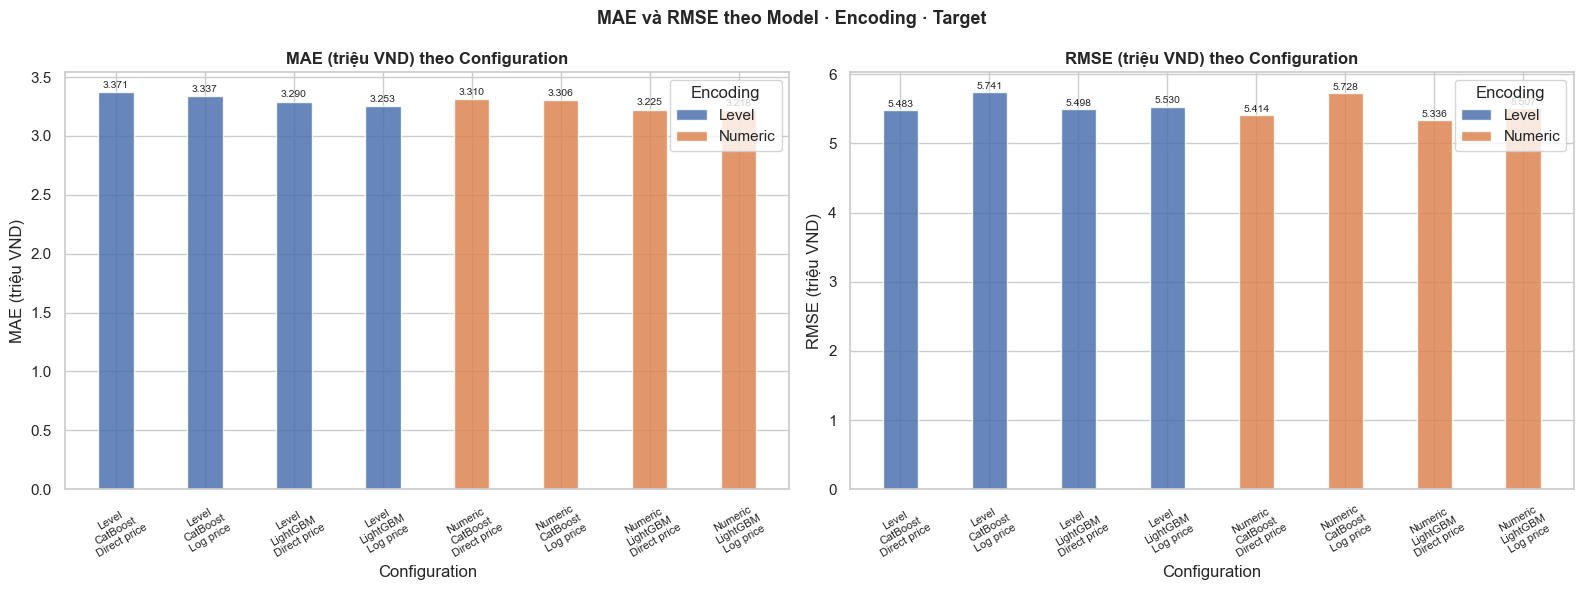

Saved: chart_mae_rmse_by_config.png


In [35]:
# ── Chart 1: MAE và RMSE by configuration ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('MAE và RMSE theo Model · Encoding · Target', fontsize=13, fontweight='bold')

palette_enc = {'Level': '#4C72B0', 'Numeric': '#DD8452'}

for ax, metric, ylabel in [(axes[0], 'mae', 'MAE (triệu VND)'), (axes[1], 'rmse', 'RMSE (triệu VND)')]:
    for enc, grp in plot_df.groupby('enc_label'):
        grp_sorted = grp.sort_values('model_name')
        x_labels = [f"{enc}\n{m}\n{t}"
                    for m, t in zip(grp_sorted['model_name'], grp_sorted['target_label'])]
        bars = ax.bar(
            x_labels, grp_sorted[metric],
            label=enc, color=palette_enc[enc], alpha=0.85, edgecolor='white', width=0.4,
        )
        for bar, val in zip(bars, grp_sorted[metric]):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
                    f'{val:.3f}', ha='center', va='bottom', fontsize=7.5)

    ax.set_title(f'{ylabel} theo Configuration', fontweight='bold')
    ax.set_xlabel('Configuration')
    ax.set_ylabel(ylabel)
    ax.tick_params(axis='x', rotation=30, labelsize=8)
    ax.legend(title='Encoding')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'chart_mae_rmse_by_config.png', dpi=160, bbox_inches='tight')
plt.show()
print('Saved: chart_mae_rmse_by_config.png')


> Các biểu đồ cho thấy `log_target_price` có thể đạt MAE/MAPE tốt hơn nhẹ ở một số mô hình, nhưng `target_price` thường cho RMSE thấp hơn và R² cao hơn trên thang giá thật. Vì chênh lệch MAE giữa hai hướng rất nhỏ, notebook ưu tiên `target_price` làm target chính và giữ `log_target_price` làm candidate phụ.


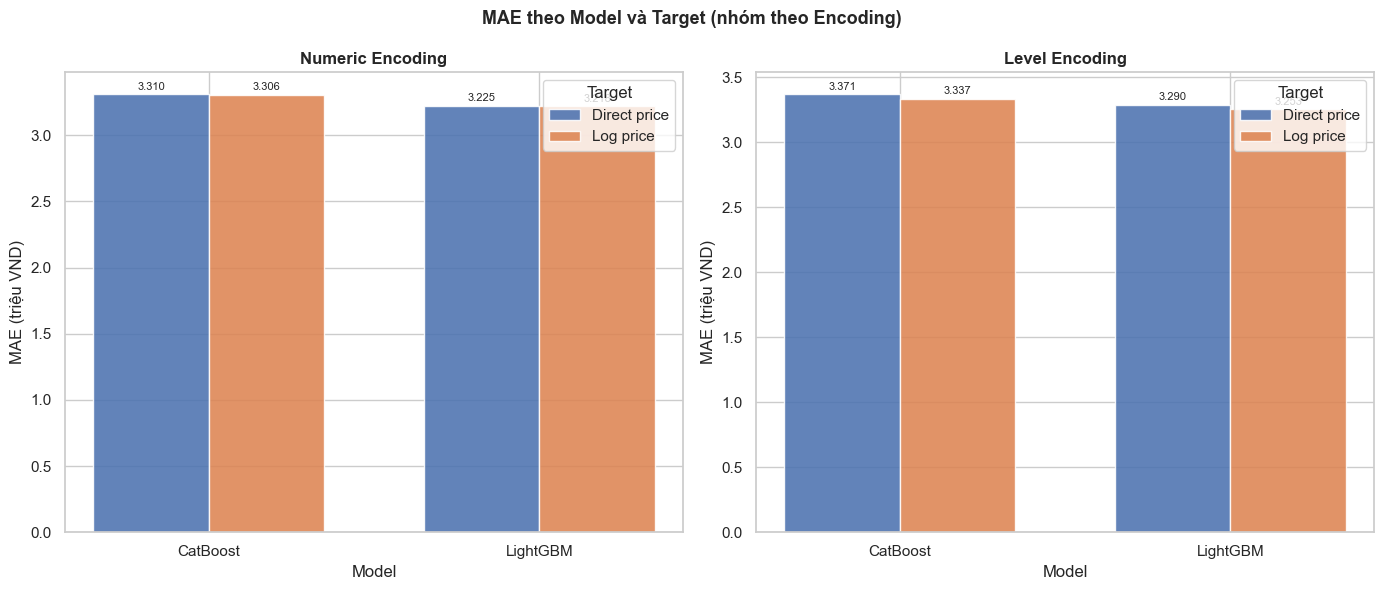

Saved: chart_mae_grouped_by_encoding.png


In [36]:
# ── Chart 2: Grouped bar — MAE by model và target, mỗi encoding riêng ────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('MAE theo Model và Target (nhóm theo Encoding)', fontsize=13, fontweight='bold')

encodings = ['numeric', 'level']
titles    = ['Numeric Encoding', 'Level Encoding']
colors    = {'Direct price': '#4C72B0', 'Log price': '#DD8452'}
x         = np.arange(len(STRONG_MODELS))
width     = 0.35

for ax, enc, title in zip(axes, encodings, titles):
    sub = plot_df[plot_df['encoding_type'] == enc]
    for i, (target_lbl, tgt_key) in enumerate([
        ('Direct price', 'target_price'),
        ('Log price', 'log_target_price'),
    ]):
        vals = [
            sub[(sub['model_name'] == m) & (sub['target_used'] == tgt_key)]['mae'].values
            for m in STRONG_MODELS
        ]
        vals = [v[0] if len(v) > 0 else np.nan for v in vals]
        offset = (i - 0.5) * width
        bars = ax.bar(x + offset, vals, width, label=target_lbl,
                      color=colors[target_lbl], edgecolor='white', alpha=0.88)
        for bar, val in zip(bars, vals):
            if not np.isnan(val):
                ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
                        f'{val:.3f}', ha='center', va='bottom', fontsize=8)

    ax.set_title(title, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(STRONG_MODELS)
    ax.set_ylabel('MAE (triệu VND)')
    ax.set_xlabel('Model')
    ax.legend(title='Target')
    ax.set_ylim(bottom=0)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'chart_mae_grouped_by_encoding.png', dpi=160, bbox_inches='tight')
plt.show()
print('Saved: chart_mae_grouped_by_encoding.png')


> Các biểu đồ cho thấy `log_target_price` có thể đạt MAE/MAPE tốt hơn nhẹ ở một số mô hình, nhưng `target_price` thường cho RMSE thấp hơn và R² cao hơn trên thang giá thật. Vì chênh lệch MAE giữa hai hướng rất nhỏ, notebook ưu tiên `target_price` làm target chính và giữ `log_target_price` làm candidate phụ.


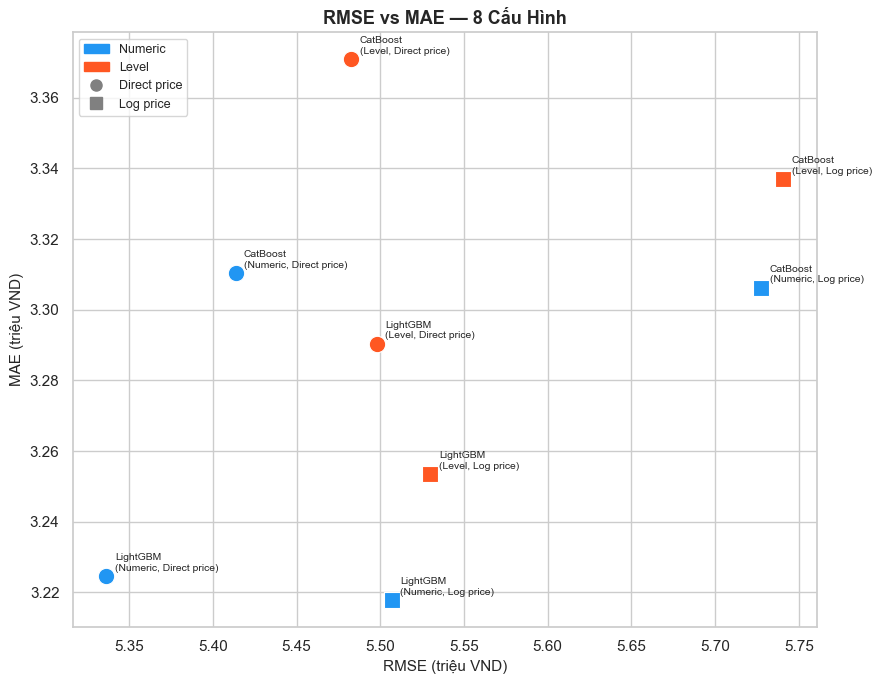

Saved: chart_scatter_rmse_vs_mae.png


In [37]:
# ── Chart 3: Scatter RMSE vs MAE ─────────────────────────────────────────────
from matplotlib.lines import Line2D

fig, ax = plt.subplots(figsize=(9, 7))

markers = {'target_price': 'o', 'log_target_price': 's'}

for _, row in plot_df.iterrows():
    ax.scatter(
        row['rmse'], row['mae'],
        marker=markers[row['target_used']],
        color=colors_enc[row['encoding_type']],
        s=140, zorder=3, edgecolors='white', linewidth=0.8,
    )
    ax.annotate(
        f"{row['model_name']}\n({row['enc_label']}, {row['target_label']})",
        (row['rmse'], row['mae']),
        textcoords='offset points', xytext=(6, 4), fontsize=7.5,
    )

legend_handles = [
    mpatches.Patch(color='#2196F3', label='Numeric'),
    mpatches.Patch(color='#FF5722', label='Level'),
    Line2D([0], [0], marker='o', color='gray', markersize=8, linestyle='None', label='Direct price'),
    Line2D([0], [0], marker='s', color='gray', markersize=8, linestyle='None', label='Log price'),
]
ax.legend(handles=legend_handles, loc='upper left', fontsize=9)
ax.set_xlabel('RMSE (triệu VND)', fontsize=11)
ax.set_ylabel('MAE (triệu VND)', fontsize=11)
ax.set_title('RMSE vs MAE — 8 Cấu Hình', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'chart_scatter_rmse_vs_mae.png', dpi=160, bbox_inches='tight')
plt.show()
print('Saved: chart_scatter_rmse_vs_mae.png')


> Các biểu đồ cho thấy `log_target_price` có thể đạt MAE/MAPE tốt hơn nhẹ ở một số mô hình, nhưng `target_price` thường cho RMSE thấp hơn và R² cao hơn trên thang giá thật. Vì chênh lệch MAE giữa hai hướng rất nhỏ, notebook ưu tiên `target_price` làm target chính và giữ `log_target_price` làm candidate phụ.


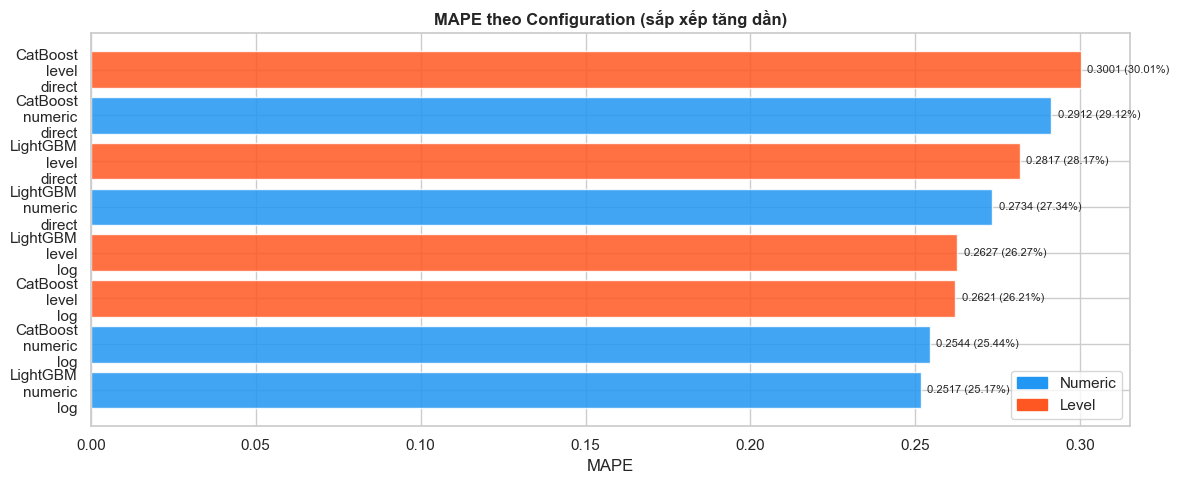

Saved: chart_mape_comparison.png


In [38]:
# ── Chart 4: MAPE comparison ─────────────────────────────────────────────────
if 'mape' in plot_df.columns and not plot_df['mape'].isna().all():
    fig, ax = plt.subplots(figsize=(12, 5))
    sub = plot_df.sort_values('mape')
    bar_colors = [colors_enc[e] for e in sub['encoding_type']]
    bars = ax.barh(sub['config'], sub['mape'], color=bar_colors, alpha=0.85, edgecolor='white')
    for bar, val in zip(bars, sub['mape']):
        ax.text(val + 0.002, bar.get_y() + bar.get_height() / 2,
                f'{val:.4f} ({val*100:.2f}%)', va='center', fontsize=8)
    ax.set_xlabel('MAPE')
    ax.set_title('MAPE theo Configuration (sắp xếp tăng dần)', fontweight='bold')
    legend_handles = [
        mpatches.Patch(color='#2196F3', label='Numeric'),
        mpatches.Patch(color='#FF5722', label='Level'),
    ]
    ax.legend(handles=legend_handles)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'chart_mape_comparison.png', dpi=160, bbox_inches='tight')
    plt.show()
    print('Saved: chart_mape_comparison.png')


> Các biểu đồ cho thấy `log_target_price` có thể đạt MAE/MAPE tốt hơn nhẹ ở một số mô hình, nhưng `target_price` thường cho RMSE thấp hơn và R² cao hơn trên thang giá thật. Vì chênh lệch MAE giữa hai hướng rất nhỏ, notebook ưu tiên `target_price` làm target chính và giữ `log_target_price` làm candidate phụ.


## 9. Balanced Decision Rule

Vì bài toán là dự đoán giá, MAE là metric quan trọng và dễ diễn giải. Tuy nhiên, nếu hai mô hình có MAE gần như tương đương, cần ưu tiên mô hình có RMSE thấp hơn và R² cao hơn để kiểm soát lỗi lớn tốt hơn.

Notebook sử dụng rule chọn model cân bằng:
- Chỉ xét kết quả được đánh giá trên `evaluation_scale == "target_price"`.
- Loại linear models khỏi candidate tuning chính; linear chỉ giữ làm reference baseline.
- Lấy các model có MAE nằm trong ngưỡng gần best MAE (`MAE_TOLERANCE = 2%`).
- Trong nhóm near-best MAE, chọn model có RMSE thấp nhất, sau đó R² cao nhất, rồi MAE thấp nhất.
- Không chọn model có RMSE/max error bất thường chỉ vì MAE thấp hơn nhẹ.


In [39]:
# ------------------------------------------------------------
# Balanced model selection on original price scale
# ------------------------------------------------------------
scored = all_results.copy()

if 'model_type' not in scored.columns:
    scored['model_type'] = scored['model_name'].apply(infer_model_type)
if 'evaluation_scale' not in scored.columns:
    scored['evaluation_scale'] = PRICE_SCALE

# Linear models are retained only as reference baselines, not tuning candidates.
tuning_candidates = scored[
    ~scored['model_type'].eq('linear')
].copy()

price_scale_results = tuning_candidates[
    tuning_candidates['evaluation_scale'].eq(PRICE_SCALE)
].copy()

price_scale_results['mae_rank'] = price_scale_results['mae'].rank(method='min', ascending=True)
price_scale_results['rmse_rank'] = price_scale_results['rmse'].rank(method='min', ascending=True)
price_scale_results['r2_rank'] = price_scale_results['r2'].rank(method='min', ascending=False)
price_scale_results['mape_rank'] = price_scale_results['mape'].rank(method='min', ascending=True)

best_mae = price_scale_results['mae'].min()

mae_near_best = price_scale_results[
    price_scale_results['mae'] <= best_mae * (1 + MAE_TOLERANCE)
].copy()

balanced_candidate = mae_near_best.sort_values(
    ['rmse', 'r2', 'mae'],
    ascending=[True, False, True]
).iloc[0]

scored = price_scale_results.sort_values(
    ['mae_rank', 'rmse_rank', 'r2_rank', 'mape_rank']
).reset_index(drop=True)
scored.index += 1

balanced_display_cols = [
    'model_name', 'model_type', 'encoding_type', 'target_used', 'evaluation_scale',
    'rmse', 'mae', 'mape', 'r2', 'mae_rank', 'rmse_rank', 'r2_rank', 'mape_rank'
]

print('=== Balanced Selection Candidates (evaluation_scale = target_price; non-linear only) ===')
display(scored[[c for c in balanced_display_cols if c in scored.columns]].style
        .apply(highlight_best, subset=['rmse', 'mae', 'mape', 'r2'])
        .format({'rmse': '{:,.4f}', 'mae': '{:,.4f}', 'mape': '{:.4f}', 'r2': '{:.4f}'}))

print('=== Near-best MAE band used for final selection ===')
display(mae_near_best[[c for c in balanced_display_cols if c in mae_near_best.columns]].sort_values(['rmse', 'r2', 'mae'], ascending=[True, False, True]))


=== Balanced Selection Candidates (evaluation_scale = target_price; non-linear only) ===


,model_name,model_type,encoding_type,target_used,evaluation_scale,rmse,mae,mape,r2,mae_rank,rmse_rank,r2_rank,mape_rank
1,LightGBM,gradient_boosting,numeric,log_target_price,target_price,5.5069,3.2178,0.2517,0.8860,1.000000,5.000000,5.000000,1.000000
2,LightGBM,gradient_boosting,numeric,target_price,target_price,5.3365,3.2246,0.2734,0.8930,2.000000,1.000000,1.000000,6.000000
3,LightGBM,gradient_boosting,level,log_target_price,target_price,5.5300,3.2535,0.2627,0.8850,3.000000,6.000000,6.000000,4.000000
4,LightGBM,gradient_boosting,level,target_price,target_price,5.4981,3.2904,0.2817,0.8864,4.000000,4.000000,4.000000,8.000000
5,CatBoost,gradient_boosting,numeric,log_target_price,target_price,5.7275,3.3062,0.2544,0.8767,5.000000,9.000000,9.000000,2.000000
6,CatBoost,gradient_boosting,numeric,target_price,target_price,5.4136,3.3104,0.2912,0.8898,6.000000,2.000000,2.000000,11.000000
7,Random Forest,tree_ensemble,numeric,target_price,target_price,5.5824,3.3197,0.2903,0.8829,7.000000,7.000000,7.000000,10.000000
8,CatBoost,gradient_boosting,level,log_target_price,target_price,5.7407,3.3370,0.2621,0.8761,8.000000,10.000000,10.000000,3.000000
9,Random Forest,tree_ensemble,numeric,log_target_price,target_price,5.7696,3.3611,0.2704,0.8749,9.000000,11.000000,11.000000,5.000000
10,CatBoost,gradient_boosting,level,target_price,target_price,5.4827,3.3709,0.3001,0.8870,10.000000,3.000000,3.000000,14.000000


=== Near-best MAE band used for final selection ===


,model_name,model_type,encoding_type,target_used,evaluation_scale,rmse,mae,mape,r2,mae_rank,rmse_rank,r2_rank,mape_rank
16,LightGBM,gradient_boosting,numeric,target_price,target_price,5.3365,3.2246,0.2734,0.8930,2.0000,1.0000,1.0000,6.0000
18,LightGBM,gradient_boosting,numeric,log_target_price,target_price,5.5069,3.2178,0.2517,0.8860,1.0000,5.0000,5.0000,1.0000
2,LightGBM,gradient_boosting,level,log_target_price,target_price,5.5300,3.2535,0.2627,0.8850,3.0000,6.0000,6.0000,4.0000


In [40]:
final_candidate = balanced_candidate.copy()
final_model_name = final_candidate['model_name']
final_target_used = final_candidate['target_used']
final_encoding_type = final_candidate['encoding_type']

best_mae_row = price_scale_results.sort_values('mae').iloc[0]
best_rmse_row = price_scale_results.sort_values('rmse').iloc[0]

print('=== Decision Rule Output ===')
print()
print('Final balanced candidate:')
print(f'  Model    : {final_model_name}')
print(f'  Encoding : {final_encoding_type}')
print(f'  Target   : {final_target_used}')
print(f'  MAE      : {final_candidate["mae"]:,.4f}')
print(f'  RMSE     : {final_candidate["rmse"]:,.4f}')
print(f'  R²       : {final_candidate["r2"]:.4f}')
print()
print('Best MAE candidate, kept for comparison if different:')
print(f'  Model    : {best_mae_row["model_name"]}')
print(f'  Encoding : {best_mae_row["encoding_type"]}')
print(f'  Target   : {best_mae_row["target_used"]}')
print(f'  MAE      : {best_mae_row["mae"]:,.4f}')
print(f'  RMSE     : {best_mae_row["rmse"]:,.4f}')
print(f'  R²       : {best_mae_row["r2"]:.4f}')
print()
print('Best RMSE candidate:')
print(f'  Model    : {best_rmse_row["model_name"]}')
print(f'  Encoding : {best_rmse_row["encoding_type"]}')
print(f'  Target   : {best_rmse_row["target_used"]}')
print(f'  RMSE     : {best_rmse_row["rmse"]:,.4f}')
print(f'  MAE      : {best_rmse_row["mae"]:,.4f}')


=== Decision Rule Output ===

Final balanced candidate:
  Model    : LightGBM
  Encoding : numeric
  Target   : target_price
  MAE      : 3.2246
  RMSE     : 5.3365
  R²       : 0.8930

Best MAE candidate, kept for comparison if different:
  Model    : LightGBM
  Encoding : numeric
  Target   : log_target_price
  MAE      : 3.2178
  RMSE     : 5.5069
  R²       : 0.8860

Best RMSE candidate:
  Model    : LightGBM
  Encoding : numeric
  Target   : target_price
  RMSE     : 5.3365
  MAE      : 3.2246


> **Nhận xét Decision Rule:**
> - MAE vẫn là metric quan trọng nhất về mặt diễn giải, vì nó cho biết trung bình mô hình dự đoán lệch bao nhiêu triệu đồng.
> - Tuy nhiên, khi MAE chênh rất nhỏ, notebook dùng RMSE và R² để chọn model cân bằng hơn trên thang giá thật.
> - Rule mới không để một cải thiện MAE/MAPE rất nhỏ của `log_target_price` lấn át RMSE/R² tốt hơn của `target_price`.
> - Linear models are retained only as reference baselines. They are not selected for fine-tuning because their performance is consistently below tree-based and boosting models. In addition, linear models with `log_target_price` may produce unstable predictions after inverse-transform on the original price scale.


## 10. Final Decision Matrix

In [41]:
# ── Final Decision Matrix ────────────────────────────────────────────────────
decision_matrix = pd.DataFrame([
    {
        'Candidate': 'LightGBM + target_price',
        'Vai trò': 'Primary candidate',
        'Lý do': 'Cân bằng tốt nhất giữa MAE, RMSE và R² trên thang giá thật. MAE gần best, trong khi RMSE/R² tốt hơn log target.',
    },
    {
        'Candidate': 'LightGBM + log_target_price',
        'Vai trò': 'MAE/MAPE alternative',
        'Lý do': 'Có thể cho MAE/MAPE tốt hơn nhẹ, nhưng RMSE/R² thường kém hơn sau inverse-transform.',
    },
    {
        'Candidate': 'CatBoost + target_price',
        'Vai trò': 'Secondary boosting baseline',
        'Lý do': 'Có hiệu năng mạnh và ổn định, đặc biệt đáng giữ nếu RMSE cạnh tranh với LightGBM.',
    },
    {
        'Candidate': 'CatBoost + log_target_price',
        'Vai trò': 'Target-strategy check',
        'Lý do': 'Dùng để kiểm tra tác động của log target trên CatBoost, không phải candidate chính.',
    },
    {
        'Candidate': 'Random Forest / Extra Trees',
        'Vai trò': 'Optional baseline',
        'Lý do': 'Có thể giữ để so sánh, nhưng thường kém hơn boosting.',
    },
    {
        'Candidate': 'Linear models',
        'Vai trò': 'Reference baseline only',
        'Lý do': 'Chỉ dùng làm baseline giải thích; không ưu tiên tuning.',
    },
])

print('=== Final Decision Matrix ===')
display(
    decision_matrix.style
    .set_properties(**{'white-space': 'pre-wrap', 'text-align': 'left'})
    .set_table_styles([{
        'selector': 'th',
        'props': [('font-weight', 'bold'), ('background-color', '#4472C4'), ('color', 'white')]
    }])
)

decision_matrix.to_csv(OUTPUT_DIR / 'final_decision_matrix.csv', index=False)
print('Saved: final_decision_matrix.csv')


=== Final Decision Matrix ===


,Candidate,Vai trò,Lý do
0,LightGBM + target_price,Primary candidate,"Cân bằng tốt nhất giữa MAE, RMSE và R² trên thang giá thật. MAE gần best, trong khi RMSE/R² tốt hơn log target."
1,LightGBM + log_target_price,MAE/MAPE alternative,"Có thể cho MAE/MAPE tốt hơn nhẹ, nhưng RMSE/R² thường kém hơn sau inverse-transform."
2,CatBoost + target_price,Secondary boosting baseline,"Có hiệu năng mạnh và ổn định, đặc biệt đáng giữ nếu RMSE cạnh tranh với LightGBM."
3,CatBoost + log_target_price,Target-strategy check,"Dùng để kiểm tra tác động của log target trên CatBoost, không phải candidate chính."
4,Random Forest / Extra Trees,Optional baseline,"Có thể giữ để so sánh, nhưng thường kém hơn boosting."
5,Linear models,Reference baseline only,Chỉ dùng làm baseline giải thích; không ưu tiên tuning.


Saved: final_decision_matrix.csv


> **Nhận xét Decision Matrix:**
> - Decision matrix phản ánh đúng vai trò của từng candidate: `LightGBM + target_price` là primary candidate, còn `log_target_price` là alternative để kiểm tra MAE/MAPE.
> - `CatBoost + target_price` được giữ như secondary boosting baseline, không phải final primary candidate.
> - Linear models chỉ giữ làm reference baseline và không đưa vào tuning chính.


## 11. Final Candidate Ranking

Top 4 candidate với role rõ ràng, không mơ hồ.


In [42]:
# ── Build final candidate ranking for Notebook 10 ─────────────────────────────
def pick_candidate(model_name: str, target_used: str, encoding_type: str = 'numeric') -> pd.Series | None:
    rows = price_scale_results[
        price_scale_results['model_name'].eq(model_name)
        & price_scale_results['target_used'].eq(target_used)
        & price_scale_results['encoding_type'].eq(encoding_type)
    ]
    if rows.empty:
        rows = price_scale_results[
            price_scale_results['model_name'].eq(model_name)
            & price_scale_results['target_used'].eq(target_used)
        ].sort_values(['rmse', 'r2', 'mae'], ascending=[True, False, True])
    if rows.empty:
        return None
    return rows.iloc[0]

ranking_specs = [
    ('LightGBM', 'target_price', 'primary_candidate', 'Balanced candidate: near-best MAE with stronger RMSE/R² on original price scale'),
    ('LightGBM', 'log_target_price', 'mae_mape_alternative', 'Alternative to test whether log target improves MAE/MAPE after tuning'),
    ('CatBoost', 'target_price', 'secondary_boosting_baseline', 'Strong boosting baseline on the primary target'),
    ('CatBoost', 'log_target_price', 'target_strategy_check', 'Checks whether CatBoost benefits from log target without making it primary'),
]

ranking_rows = []
for rank, (model_name, target_used, role, reason) in enumerate(ranking_specs, start=1):
    row = pick_candidate(model_name, target_used, 'numeric')
    if row is None:
        continue
    row = row.copy()
    row['rank'] = rank
    row['role'] = role
    row['reason'] = reason
    ranking_rows.append(row)

top4 = pd.DataFrame(ranking_rows)
cols_display = ['rank', 'model_name', 'encoding_type', 'target_used', 'evaluation_scale',
                'rmse', 'mae', 'mape', 'r2', 'role', 'reason']
top4_display = top4[[c for c in cols_display if c in top4.columns]]

print('=== Final Candidate Ranking ===')
display(top4_display.style.format(
    {'rmse': '{:,.4f}', 'mae': '{:,.4f}', 'mape': '{:.4f}', 'r2': '{:.4f}'}
))

top4_display.to_csv(OUTPUT_DIR / 'final_candidate_ranking.csv', index=False)
top4_display.to_csv(OUTPUT_DIR / 'final_candidates.csv', index=False)
print('Saved: final_candidate_ranking.csv')
print('Saved: final_candidates.csv')


=== Final Candidate Ranking ===


,rank,model_name,encoding_type,target_used,evaluation_scale,rmse,mae,mape,r2,role,reason
16,1,LightGBM,numeric,target_price,target_price,5.3365,3.2246,0.2734,0.8930,primary_candidate,Balanced candidate: near-best MAE with stronger RMSE/R² on original price scale
18,2,LightGBM,numeric,log_target_price,target_price,5.5069,3.2178,0.2517,0.8860,mae_mape_alternative,Alternative to test whether log target improves MAE/MAPE after tuning
17,3,CatBoost,numeric,target_price,target_price,5.4136,3.3104,0.2912,0.8898,secondary_boosting_baseline,Strong boosting baseline on the primary target
20,4,CatBoost,numeric,log_target_price,target_price,5.7275,3.3062,0.2544,0.8767,target_strategy_check,Checks whether CatBoost benefits from log target without making it primary


Saved: final_candidate_ranking.csv
Saved: final_candidates.csv


> **Nhận xét Final Ranking:**
> - **Rank 1:** `LightGBM + numeric + target_price` là cấu hình đi tiếp đầu tiên cho notebook 10.
> - **Rank 2:** `LightGBM + numeric + log_target_price` là MAE/MAPE alternative, dùng để kiểm tra lợi ích của log target sau tuning.
> - **Rank 3:** `CatBoost + numeric + target_price` là secondary boosting baseline.
> - **Rank 4:** `CatBoost + numeric + log_target_price` là target-strategy check, không phải candidate chính.
> - Các cấu hình level vẫn hữu ích như đối chứng ổn định, nhưng handoff chính sang notebook 10 ưu tiên numeric representation.


## 12. Overall Summary

Kết quả từ notebook 08a và 08b cho thấy nhóm gradient boosting tiếp tục là nhóm mô hình mạnh nhất cho bài toán dự đoán giá laptop. Trong đó, `LightGBM` và `CatBoost` là hai mô hình ổn định nhất.

Ở cả hai hướng feature representation (`level` và `numeric`), `LightGBM + target_price` nổi lên như candidate cân bằng nhất. Mặc dù `LightGBM + log_target_price` có thể đạt MAE hoặc MAPE tốt hơn nhẹ, mức cải thiện này rất nhỏ. Ngược lại, `LightGBM + target_price` thường cho RMSE thấp hơn và R² cao hơn trên thang giá thật.

Vì mục tiêu cuối cùng là dự đoán giá laptop theo đơn vị triệu VND, notebook này chọn `LightGBM + target_price` làm candidate chính cho bước tuning tiếp theo. `log_target_price` được giữ lại làm candidate phụ để kiểm tra liệu việc tối ưu MAE/MAPE có cải thiện thêm sau tuning hay không.


In [43]:
# ── Final recommendation summary and text artifact ───────────────────────────
print('=' * 70)
print('FINAL CANDIDATE — NOTEBOOK 09')
print('=' * 70)
print()
print('Primary candidate:')
print(f'  Model            : {final_candidate["model_name"]}')
print(f'  Feature encoding : {final_candidate["encoding_type"]}')
print(f'  Target           : {final_candidate["target_used"]}')
print(f'  Evaluation scale : {final_candidate["evaluation_scale"]}')
print(f'  MAE              : {final_candidate["mae"]:,.4f}')
print(f'  RMSE             : {final_candidate["rmse"]:,.4f}')
print(f'  R²               : {final_candidate["r2"]:.4f}')
print()
print('Secondary candidates:')
for _, row in top4_display.iloc[1:].iterrows():
    print(f'  - {row["model_name"]} + {row["encoding_type"]} + {row["target_used"]} [{row["role"]}]')
print('=' * 70)

RECOMMENDATION_PATH = OUTPUT_DIR / 'conclusion_09.txt'
rec_lines_full = [
    'Final Recommendation',
    '====================',
    '',
    'Primary candidate:',
    f'  Model: {final_candidate["model_name"]}',
    f'  Feature representation: {final_candidate["encoding_type"]}',
    f'  Target: {final_candidate["target_used"]}',
    f'  Evaluation scale: {final_candidate["evaluation_scale"]}',
    f'  MAE: {final_candidate["mae"]:.4f}',
    f'  RMSE: {final_candidate["rmse"]:.4f}',
    f'  R2: {final_candidate["r2"]:.4f}',
    '',
    'Recommended fine-tuning candidates:',
    '  1. LightGBM + target_price      [Primary candidate]',
    '  2. LightGBM + log_target_price  [MAE/MAPE alternative]',
    '  3. CatBoost + target_price      [Secondary boosting baseline]',
    '  4. CatBoost + log_target_price  [Target-strategy check]',
    '',
    'Decision:',
    '  target_price is selected as the primary target because it provides',
    '  better balanced performance on the original price scale. log_target_price',
    '  is retained as a secondary candidate because it may slightly improve MAE/MAPE.',
    '',
    'Notebook 10 handoff:',
    '  Start with LightGBM + target_price on numeric feature representation.',
    '  Then compare against LightGBM + log_target_price, CatBoost + target_price,',
    '  and CatBoost + log_target_price using the same split or cross-validation.',
    '',
    'Next step:',
    '  Tune LightGBM + target_price first, then compare against the secondary candidates',
    '  using cross-validation and residual analysis by price_range, brand, CPU tier,',
    '  GPU type, condition, and warranty.',
]

with open(RECOMMENDATION_PATH, 'w', encoding='utf-8') as f:
    f.write('\n'.join(rec_lines_full))

print(f'Saved: {RECOMMENDATION_PATH.name}')


FINAL CANDIDATE — NOTEBOOK 09

Primary candidate:
  Model            : LightGBM
  Feature encoding : numeric
  Target           : target_price
  Evaluation scale : target_price
  MAE              : 3.2246
  RMSE             : 5.3365
  R²               : 0.8930

Secondary candidates:
  - LightGBM + numeric + log_target_price [mae_mape_alternative]
  - CatBoost + numeric + target_price [secondary_boosting_baseline]
  - CatBoost + numeric + log_target_price [target_strategy_check]
Saved: conclusion_09.txt


---

## Final Decision

Dựa trên kết quả từ notebook 08a và 08b, `target_price` được chọn làm target chính cho bước tuning tiếp theo. Lý do là mục tiêu cuối cùng của bài toán là dự đoán giá laptop trên thang giá thật, đơn vị triệu VND.

MAE vẫn được xem là metric quan trọng nhất về mặt diễn giải, vì nó cho biết trung bình mô hình dự đoán lệch bao nhiêu triệu đồng. Tuy nhiên, trong kết quả hiện tại, chênh lệch MAE giữa `LightGBM + log_target_price` và `LightGBM + target_price` rất nhỏ. Vì vậy, lợi ích của log target về MAE/MAPE chưa đủ lớn để bù lại việc `target_price` có RMSE tốt hơn, R² cao hơn và kiểm soát lỗi lớn tốt hơn.

Candidate chính cho bước tiếp theo là:

`numeric + LightGBM + target_price`

Các candidate phụ nên giữ lại để so sánh:

- `numeric + LightGBM + log_target_price`
- `numeric + CatBoost + target_price`
- `numeric + CatBoost + log_target_price`

Nhóm linear models chỉ nên giữ làm baseline tham khảo, không đưa vào tuning chính.

## Handoff to Notebook 10

Notebook 10 nên bắt đầu với candidate chính là `LightGBM + target_price` trên numeric feature representation. Đây là lựa chọn cân bằng nhất từ notebook 08 và 09, vì MAE gần best nhất nhưng RMSE/R² tốt hơn so với log target.

Các candidate phụ cần giữ lại để so sánh sau tuning gồm `LightGBM + log_target_price`, `CatBoost + target_price` và `CatBoost + log_target_price`. Việc so sánh sau tuning nên dùng cùng split hoặc cross-validation, đồng thời phân tích residual theo từng phân khúc giá và nhóm cấu hình.


## 13. Save Final Artifacts

In [44]:
print('=== Artifacts saved to', OUTPUT_DIR, '===')
for f in sorted(OUTPUT_DIR.iterdir()):
    size_kb = f.stat().st_size / 1024
    print(f'  {f.name:<55}  {size_kb:6.1f} KB')


=== Artifacts saved to Y:\Python\Laptop-Price-Prediction\artifacts\level_numeric_comparison ===
  chart_mae_grouped_by_encoding.png                          70.9 KB
  chart_mae_rmse_by_config.png                              107.7 KB
  chart_mape_comparison.png                                  90.2 KB
  chart_scatter_rmse_vs_mae.png                              79.1 KB
  conclusion_09.txt                                           1.2 KB
  encoding_comparison_delta.csv                               0.9 KB
  final_candidate_ranking.csv                                 0.9 KB
  final_candidates.csv                                        0.9 KB
  final_decision_matrix.csv                                   0.9 KB
  main_comparison_table.csv                                   0.9 KB
  rmse_penalty_analysis.csv                                   1.0 KB
  target_comparison_delta.csv                                 1.1 KB
